# Two-stage ensemble with tie-break

Logic:
- For each utterance, take annotations from two **different** models (A, B), each in either zero-shot or few-shot configuration.
- If A and B fully agree (same strategy1 AND same strategy2) → use that label.
- If A and B disagree → ask a **third** model (different from A and B) to choose between A's pair and B's pair.
- Third model priority by cost: mistral (free) → cohere → anthropic.
- Third model uses its own prompt - it sees the fragment, both annotations, both explanations, and picks A or B.

In [ ]:
!pip -q install openai anthropic cohere pandas tqdm scikit-learn requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.5/350.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 28.7 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass
import json
import re
import time
import requests
import pandas as pd

from itertools import combinations
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer

from openai import OpenAI
from anthropic import Anthropic
import cohere

os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API key: ").strip()
os.environ["MISTRAL_API_KEY"] = getpass("Mistral API key: ").strip()
os.environ["COHERE_API_KEY"] = getpass("Cohere API key: ").strip()

anthropic_client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
cohere_client = cohere.ClientV2(
    api_key=os.environ["COHERE_API_KEY"],
    log_warning_experimental_features=False
)

zs = pd.read_csv("zero_shot_results.csv", sep=";")
fs = pd.read_csv("few_shot_results.csv", sep=";")

print(f"zero-shot rows: {len(zs)}")
print(f"few-shot rows: {len(fs)}")

Anthropic API key: ··········
Mistral API key: ··········
Cohere API key: ··········
zero-shot rows: 354
few-shot rows: 354


In [ ]:
def extract_json(raw_text):
    if raw_text is None:
        return {"choice": None, "explanation": "Empty response"}

    raw_text = str(raw_text).strip()
    raw_text = raw_text.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    return {"choice": None, "explanation": f"Could not parse JSON: {raw_text[:300]}"}

In [ ]:
MODELS = ["mistral", "cohere", "openai", "anthropic"]
PROMPTING = ["zs", "fs"]

base_cols = ["link", "order", "text", "speaker", "gold_strategy1", "gold_strategy2"]
result_df = zs[base_cols].copy()

for model in MODELS:
    for col in ["strategy1", "strategy2", "explanation"]:
        result_df[f"{model}_zs_{col}"] = zs[f"{model}_{col}"].values
        result_df[f"{model}_fs_{col}"] = fs[f"{model}_{col}"].values

print(f"Total rows: {len(result_df)}")
print(f"Columns: {len(result_df.columns)}")
print(result_df.columns.tolist()[:10], "...")

Total rows: 354
Columns: 30
['link', 'order', 'text', 'speaker', 'gold_strategy1', 'gold_strategy2', 'mistral_zs_strategy1', 'mistral_fs_strategy1', 'mistral_zs_strategy2', 'mistral_fs_strategy2'] ...


In [ ]:
EMPTY_VALUES = {"", "nan", "none", "null"}

def normalize_strategy_value(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in EMPTY_VALUES or s == "-":
        return None
    return s

def pair_equal(s1_a, s2_a, s1_b, s2_b):
    return (normalize_strategy_value(s1_a) == normalize_strategy_value(s1_b) and
            normalize_strategy_value(s2_a) == normalize_strategy_value(s2_b))

In [ ]:
TIE_BREAK_PROMPT = """You are an expert annotator of rhetorical strategies in U.S. presidential and vice-presidential debate transcripts. Two annotators have labeled the following debate fragment differently. Your task is to choose which annotation is more accurate.

## Taxonomy
1. 'presentation' (positive framing, self-presentation) - speaker explicitly represents themselves, their party, their candidate, situation, event, policy outcome, or trend in a positive light. Positive evaluation of a situation counts as presentation only when the speaker associates the positive outcome with their own side.
2. 'accusation' (negative framing of others) - speaker attributes blame or wrongdoing to an opponent, or describes a situation, event, or trend negatively while attributing the cause to a specific actor.
3. 'self-justification' - speaker's main rhetorical move is to deny, explain, or contextualize a specific accusation against themselves or their record.
4. 'appeal' - an audience-oriented rhetorical move: a direct call to the audience to act, vote, support, or adopt a position, or a broader appeal that invokes shared values, identity, or collective responsibility, or emotional storytelling addressed to the audience to mobilize support.

Special labels:
- '-' - moderator or question-asker utterance.
- 'no_strategy' - fragment is too short, interrupted, purely emotional, procedural, or lacks sufficient context to identify a strategy.

## Note on the accusation+presentation pair
When both annotators agree the pair is {accusation, presentation}, the canonical order is strategy1='accusation', strategy2='presentation'.

## Your task
You will be given:
- the debate fragment,
- annotation A (strategy1, strategy2, explanation),
- annotation B (strategy1, strategy2, explanation).

Pick the more accurate annotation as a whole pair. You must choose either "A" or "B" - do not propose a third option.

Return strictly valid JSON, no extra text:
{
  "choice": "A" or "B",
  "explanation": "one sentence explaining your choice"
}
"""

def build_tie_break_user_message(text, a_s1, a_s2, a_expl, b_s1, b_s2, b_expl):
    a_s2 = a_s2 if (a_s2 and str(a_s2).strip().lower() not in EMPTY_VALUES) else "null"
    b_s2 = b_s2 if (b_s2 and str(b_s2).strip().lower() not in EMPTY_VALUES) else "null"
    return f"""## Fragment
{text}

## Annotation A
strategy1: {a_s1}
strategy2: {a_s2}
explanation: {a_expl}

## Annotation B
strategy1: {b_s1}
strategy2: {b_s2}
explanation: {b_expl}
"""

In [ ]:
def tie_break_mistral(user_msg, model="mistral-small-latest", max_retries=6):
    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {os.environ['MISTRAL_API_KEY']}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": model,
        "temperature": 0,
        "messages": [
            {"role": "system", "content": TIE_BREAK_PROMPT},
            {"role": "user", "content": user_msg}
        ],
        "response_format": {"type": "json_object"}
    }
    for attempt in range(max_retries):
        r = requests.post(url, headers=headers, json=payload, timeout=120)
        if r.status_code == 429:
            wait = 2 ** (attempt + 2)
            time.sleep(wait)
            continue
        r.raise_for_status()
        data = r.json()
        return extract_json(data["choices"][0]["message"]["content"])
    raise RuntimeError("Mistral rate limit after retries")


TIE_BREAK_SCHEMA_COHERE = {
    "type": "object",
    "required": ["choice", "explanation"],
    "properties": {
        "choice": {"type": "string", "enum": ["A", "B"]},
        "explanation": {"type": "string"}
    }
}

def tie_break_cohere(user_msg, model="command-a-03-2025"):
    response = cohere_client.chat(
        model=model,
        messages=[
            {"role": "system", "content": TIE_BREAK_PROMPT},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        max_tokens=300,
        response_format={"type": "json_object", "schema": TIE_BREAK_SCHEMA_COHERE}
    )
    return extract_json(response.message.content[0].text)


TIE_BREAK_TOOL_ANTHROPIC = {
    "name": "choose_annotation",
    "description": "Choose which of the two annotations (A or B) is more accurate.",
    "input_schema": {
        "type": "object",
        "properties": {
            "choice": {"type": "string", "enum": ["A", "B"]},
            "explanation": {"type": "string"}
        },
        "required": ["choice", "explanation"],
        "additionalProperties": False
    }
}

def tie_break_anthropic(user_msg, model="claude-sonnet-4-5"):
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=300,
        temperature=0,
        system=TIE_BREAK_PROMPT,
        messages=[{"role": "user", "content": user_msg}],
        tools=[TIE_BREAK_TOOL_ANTHROPIC],
        tool_choice={"type": "tool", "name": "choose_annotation"}
    )
    tool_use = next(b for b in response.content if b.type == "tool_use")
    return dict(tool_use.input)


TIE_BREAK_FUNCS = {
    "mistral": tie_break_mistral,
    "cohere": tie_break_cohere,
    "anthropic": tie_break_anthropic,
}

In [ ]:
CONFIGS = [(m, p) for m in MODELS for p in PROMPTING]

PAIRS = []
for (m1, p1), (m2, p2) in combinations(CONFIGS, 2):
    if m1 == m2:
        continue
    PAIRS.append(((m1, p1), (m2, p2)))

print(f"Pairs found: {len(PAIRS)}")
for p in PAIRS:
    print(f"  {p[0][0]}-{p[0][1]} + {p[1][0]}-{p[1][1]}")

Pairs found: 24
  mistral-zs + cohere-zs
  mistral-zs + cohere-fs
  mistral-zs + openai-zs
  mistral-zs + openai-fs
  mistral-zs + anthropic-zs
  mistral-zs + anthropic-fs
  mistral-fs + cohere-zs
  mistral-fs + cohere-fs
  mistral-fs + openai-zs
  mistral-fs + openai-fs
  mistral-fs + anthropic-zs
  mistral-fs + anthropic-fs
  cohere-zs + openai-zs
  cohere-zs + openai-fs
  cohere-zs + anthropic-zs
  cohere-zs + anthropic-fs
  cohere-fs + openai-zs
  cohere-fs + openai-fs
  cohere-fs + anthropic-zs
  cohere-fs + anthropic-fs
  openai-zs + anthropic-zs
  openai-zs + anthropic-fs
  openai-fs + anthropic-zs
  openai-fs + anthropic-fs


In [ ]:
THIRD_PRIORITY = ["mistral", "cohere", "anthropic"]

def select_third(pair):
    (m1, _), (m2, _) = pair
    used = {m1, m2}
    for candidate in THIRD_PRIORITY:
        if candidate not in used:
            return candidate
    raise ValueError("No third model available")

for pair in PAIRS:
    third = select_third(pair)
    print(f"{pair[0][0]}-{pair[0][1]} + {pair[1][0]}-{pair[1][1]} → third = {third}")

mistral-zs + cohere-zs → third = anthropic
mistral-zs + cohere-fs → third = anthropic
mistral-zs + openai-zs → third = cohere
mistral-zs + openai-fs → third = cohere
mistral-zs + anthropic-zs → third = cohere
mistral-zs + anthropic-fs → third = cohere
mistral-fs + cohere-zs → third = anthropic
mistral-fs + cohere-fs → third = anthropic
mistral-fs + openai-zs → third = cohere
mistral-fs + openai-fs → third = cohere
mistral-fs + anthropic-zs → third = cohere
mistral-fs + anthropic-fs → third = cohere
cohere-zs + openai-zs → third = mistral
cohere-zs + openai-fs → third = mistral
cohere-zs + anthropic-zs → third = mistral
cohere-zs + anthropic-fs → third = mistral
cohere-fs + openai-zs → third = mistral
cohere-fs + openai-fs → third = mistral
cohere-fs + anthropic-zs → third = mistral
cohere-fs + anthropic-fs → third = mistral
openai-zs + anthropic-zs → third = mistral
openai-zs + anthropic-fs → third = mistral
openai-fs + anthropic-zs → third = mistral
openai-fs + anthropic-fs → third = 

In [ ]:
# Для каждой пары считаем % полного согласия (strategy1 AND strategy2 совпадают) и accuracy на согласных строках.

eval_mask = result_df['gold_strategy1'].notna() & (result_df['gold_strategy1'] != '-')
eval_df = result_df[eval_mask].copy().reset_index(drop=True)
print(f"Rows with gold: {len(eval_df)}")

agreement_stats = []
for (m1, p1), (m2, p2) in PAIRS:
    a_s1 = eval_df[f"{m1}_{p1}_strategy1"]
    a_s2 = eval_df[f"{m1}_{p1}_strategy2"]
    b_s1 = eval_df[f"{m2}_{p2}_strategy1"]
    b_s2 = eval_df[f"{m2}_{p2}_strategy2"]

    agree = [pair_equal(a_s1[i], a_s2[i], b_s1[i], b_s2[i]) for i in range(len(eval_df))]
    agree_pct = sum(agree) / len(agree)

    # accuracy на согласных строках (по strategy1)
    gold = eval_df['gold_strategy1'].apply(normalize_strategy_value)
    agree_correct = sum(1 for i in range(len(eval_df))
                        if agree[i] and normalize_strategy_value(a_s1[i]) == gold[i])
    agree_acc = agree_correct / sum(agree) if sum(agree) > 0 else 0

    agreement_stats.append({
        "pair": f"{m1}-{p1} + {m2}-{p2}",
        "third": select_third(((m1, p1), (m2, p2))),
        "agree_count": sum(agree),
        "agree_pct": agree_pct,
        "disagree_count": len(eval_df) - sum(agree),
        "agree_strategy1_acc": agree_acc,
    })

stats_df = pd.DataFrame(agreement_stats).sort_values("agree_pct", ascending=False)
print(stats_df.to_string(index=False))

Rows with gold: 353
                     pair     third  agree_count  agree_pct  disagree_count  agree_strategy1_acc
 openai-zs + anthropic-zs   mistral          267   0.756374              86             0.921348
    cohere-fs + openai-zs   mistral          261   0.739377              92             0.934866
 openai-fs + anthropic-zs   mistral          261   0.739377              92             0.911877
    cohere-fs + openai-fs   mistral          260   0.736544              93             0.926923
 openai-fs + anthropic-fs   mistral          259   0.733711              94             0.918919
   mistral-fs + cohere-fs anthropic          258   0.730878              95             0.903101
 openai-zs + anthropic-fs   mistral          256   0.725212              97             0.933594
 cohere-fs + anthropic-zs   mistral          255   0.722380              98             0.933333
 cohere-fs + anthropic-fs   mistral          252   0.713881             101             0.928571
    cohere

In [ ]:
tie_break_cache = {}

def call_third(third_model, row_idx, text, a_s1, a_s2, a_expl, b_s1, b_s2, b_expl):
    cache_key = (third_model, row_idx,
                 normalize_strategy_value(a_s1), normalize_strategy_value(a_s2),
                 normalize_strategy_value(b_s1), normalize_strategy_value(b_s2))
    if cache_key in tie_break_cache:
        return tie_break_cache[cache_key]
    user_msg = build_tie_break_user_message(text, a_s1, a_s2, a_expl, b_s1, b_s2, b_expl)
    try:
        result = TIE_BREAK_FUNCS[third_model](user_msg)
        if result.get("choice") not in ("A", "B"):
            result = {"choice": None, "explanation": f"Invalid choice: {result.get('choice')}"}
    except Exception as e:
        result = {"choice": None, "explanation": f"Error: {e}"}
    tie_break_cache[cache_key] = result
    if third_model == "mistral":
        time.sleep(3)
    return result

In [ ]:
# Прогон tie-break для всех 12 пар.
# Для каждой пары:
#   - находим расхождения
#   - спрашиваем третью модель → она выбирает A или B
#   - формируем итоговую разметку пары (consensus или choice)
# Сохраняем итоговые ensemble_s1, ensemble_s2 для каждой пары в отдельных колонках eval_df.

for pair_idx, ((m1, p1), (m2, p2)) in enumerate(PAIRS):
    third = select_third(((m1, p1), (m2, p2)))
    pair_name = f"{m1[:3]}{p1}_{m2[:3]}{p2}_via_{third[:3]}"
    print(f"\n[{pair_idx+1}/{len(PAIRS)}] {m1}-{p1} + {m2}-{p2}  →  third = {third}")

    ens_s1 = []
    ens_s2 = []
    n_disagree = 0
    n_third_errors = 0

    for i in tqdm(range(len(eval_df)), desc=pair_name):
        row = eval_df.iloc[i]
        a_s1 = row[f"{m1}_{p1}_strategy1"]
        a_s2 = row[f"{m1}_{p1}_strategy2"]
        a_expl = row[f"{m1}_{p1}_explanation"]
        b_s1 = row[f"{m2}_{p2}_strategy1"]
        b_s2 = row[f"{m2}_{p2}_strategy2"]
        b_expl = row[f"{m2}_{p2}_explanation"]

        if pair_equal(a_s1, a_s2, b_s1, b_s2):
            ens_s1.append(a_s1)
            ens_s2.append(a_s2)
            continue

        n_disagree += 1
        result = call_third(third, i, row['text'], a_s1, a_s2, a_expl, b_s1, b_s2, b_expl)
        choice = result.get("choice")

        if choice == "A":
            ens_s1.append(a_s1)
            ens_s2.append(a_s2)
        elif choice == "B":
            ens_s1.append(b_s1)
            ens_s2.append(b_s2)
        else:
            n_third_errors += 1
            ens_s1.append(a_s1)
            ens_s2.append(a_s2)

    eval_df[f"{pair_name}_strategy1"] = ens_s1
    eval_df[f"{pair_name}_strategy2"] = ens_s2
    print(f"  disagreements: {n_disagree}, third-errors: {n_third_errors}")


[1/24] mistral-zs + cohere-zs  →  third = anthropic


miszs_cohzs_via_ant: 100%|██████████| 353/353 [08:46<00:00,  1.49s/it]


  disagreements: 147, third-errors: 0

[2/24] mistral-zs + cohere-fs  →  third = anthropic


miszs_cohfs_via_ant: 100%|██████████| 353/353 [01:19<00:00,  4.42it/s]


  disagreements: 123, third-errors: 0

[3/24] mistral-zs + openai-zs  →  third = cohere


...

  disagreements: 97, third-errors: 0

[23/24] openai-fs + anthropic-zs  →  third = mistral


opefs_antzs_via_mis: 100%|██████████| 353/353 [01:07<00:00,  5.24it/s]


  disagreements: 92, third-errors: 0

[24/24] openai-fs + anthropic-fs  →  third = mistral


opefs_antfs_via_mis: 100%|██████████| 353/353 [00:07<00:00, 46.73it/s]

  disagreements: 94, third-errors: 0


In [ ]:
def to_strategy_set(t1, t2):
    strategies = set()
    for t in [t1, t2]:
        n = normalize_strategy_value(t)
        if n is not None:
            strategies.add(n)
    return strategies

ensemble_metrics = []
for ((m1, p1), (m2, p2)) in PAIRS:
    third = select_third(((m1, p1), (m2, p2)))
    pair_name = f"{m1[:3]}{p1}_{m2[:3]}{p2}_via_{third[:3]}"

    gold_set = eval_df.apply(
        lambda r: to_strategy_set(r['gold_strategy1'], r['gold_strategy2']), axis=1
    )
    ens_set = eval_df.apply(
        lambda r: to_strategy_set(r[f"{pair_name}_strategy1"], r[f"{pair_name}_strategy2"]), axis=1
    )

    gold_s1_norm = eval_df['gold_strategy1'].apply(normalize_strategy_value)
    ens_s1_norm = eval_df[f"{pair_name}_strategy1"].apply(normalize_strategy_value)

    strict_acc = (gold_s1_norm == ens_s1_norm).mean()
    set_acc = (gold_set == ens_set).mean()
    primary_recall = [(gold_s1_norm.iloc[i] in ens_set.iloc[i]) for i in range(len(eval_df))]
    primary_recall = sum(primary_recall) / len(primary_recall)

    ensemble_metrics.append({
        "pair": f"{m1}-{p1} + {m2}-{p2}",
        "third": third,
        "strict_acc": strict_acc,
        "exact_set_acc": set_acc,
        "primary_recall": primary_recall,
    })

ensemble_df = pd.DataFrame(ensemble_metrics).sort_values("strict_acc", ascending=False)
print("=== Ensemble results (sorted by strict accuracy) ===")
print(ensemble_df.to_string(index=False))

=== Ensemble results (sorted by strict accuracy) ===
                     pair     third  strict_acc  exact_set_acc  primary_recall
   mistral-fs + cohere-zs anthropic    0.855524       0.762040        0.869688
   mistral-fs + cohere-fs anthropic    0.855524       0.767705        0.878187
mistral-zs + anthropic-zs    cohere    0.847025       0.722380        0.900850
mistral-fs + anthropic-zs    cohere    0.844193       0.742210        0.898017
   mistral-zs + openai-fs    cohere    0.838527       0.730878        0.869688
   mistral-zs + cohere-fs anthropic    0.838527       0.730878        0.866856
 openai-fs + anthropic-zs   mistral    0.838527       0.759207        0.886686
   mistral-zs + cohere-zs anthropic    0.832861       0.725212        0.852691
 openai-fs + anthropic-fs   mistral    0.832861       0.773371        0.889518
   mistral-zs + openai-zs    cohere    0.832861       0.722380        0.872521
   mistral-fs + openai-fs    cohere    0.832861       0.747875        0.866856

## Visualizations and ensemble selection

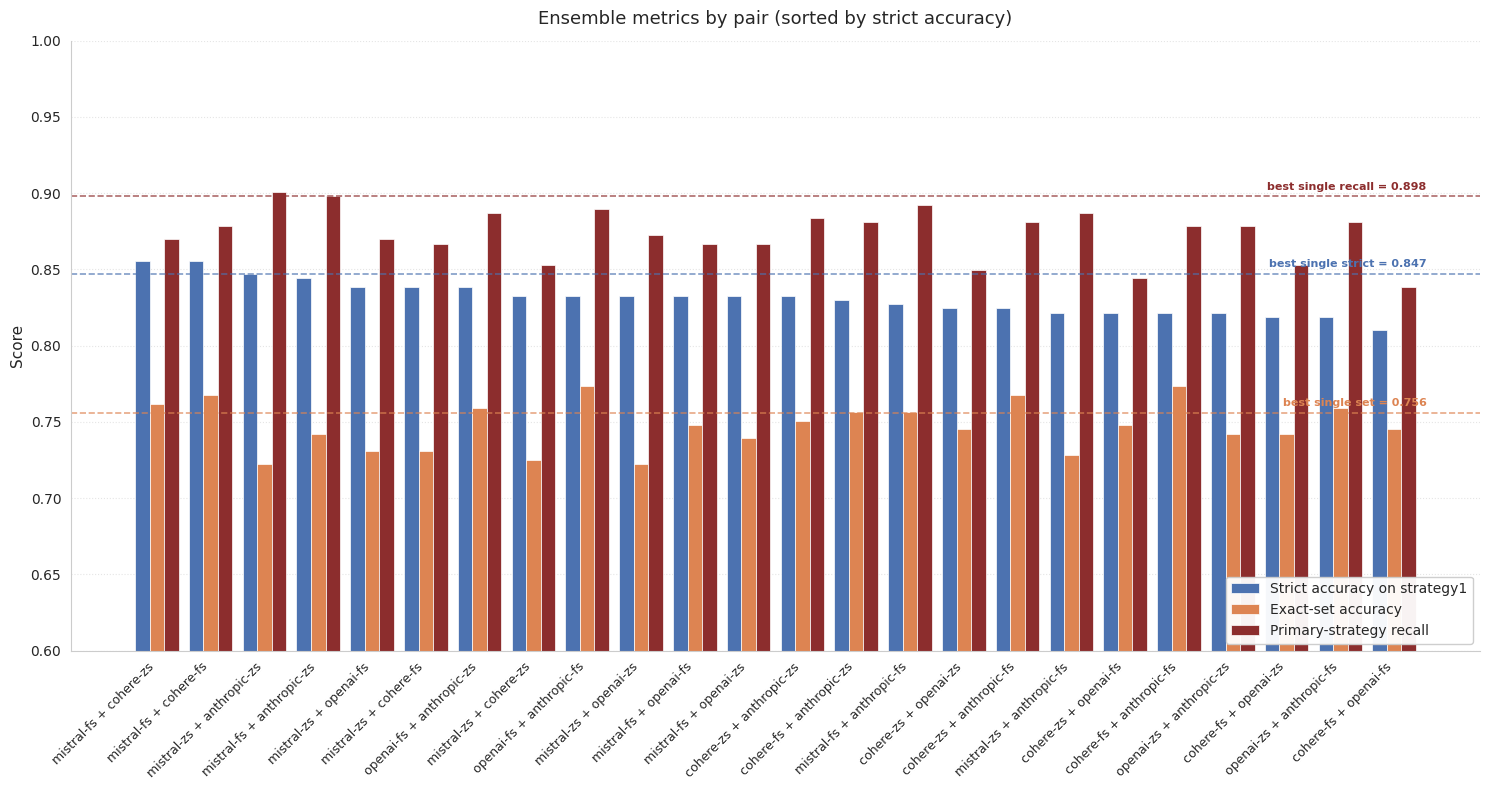

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("whitegrid")

COLOR_STRICT = "#4C72B0"
COLOR_SET    = "#DD8452"
COLOR_RECALL = "#8C2D2D"

# best single — Anthropic-zs
BEST_SINGLE = {
    "strict":  0.847,
    "set":     0.756,
    "recall":  0.898,
}

fig, ax = plt.subplots(figsize=(15, 8))
x = np.arange(len(ensemble_df))
width = 0.27

ax.bar(x - width, ensemble_df["strict_acc"],     width,
       label="Strict accuracy on strategy1",
       color=COLOR_STRICT, edgecolor="white", linewidth=0.5)
ax.bar(x,         ensemble_df["exact_set_acc"],  width,
       label="Exact-set accuracy",
       color=COLOR_SET,    edgecolor="white", linewidth=0.5)
ax.bar(x + width, ensemble_df["primary_recall"], width,
       label="Primary-strategy recall",
       color=COLOR_RECALL, edgecolor="white", linewidth=0.5)

ax.axhline(BEST_SINGLE["strict"], color=COLOR_STRICT, linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(BEST_SINGLE["set"],    color=COLOR_SET,    linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(BEST_SINGLE["recall"], color=COLOR_RECALL, linestyle="--", linewidth=1.2, alpha=0.7)

x_text = len(ensemble_df) - 0.4
ax.text(x_text, BEST_SINGLE["strict"] + 0.003, f"best single strict = {BEST_SINGLE['strict']:.3f}",
        fontsize=8, color=COLOR_STRICT, ha="right", va="bottom", fontweight="bold")
ax.text(x_text, BEST_SINGLE["set"]    + 0.003, f"best single set = {BEST_SINGLE['set']:.3f}",
        fontsize=8, color=COLOR_SET,    ha="right", va="bottom", fontweight="bold")
ax.text(x_text, BEST_SINGLE["recall"] + 0.003, f"best single recall = {BEST_SINGLE['recall']:.3f}",
        fontsize=8, color=COLOR_RECALL, ha="right", va="bottom", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(ensemble_df["pair"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Ensemble metrics by pair (sorted by strict accuracy)",
             fontsize=13, pad=12)
ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))

ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

ax.legend(loc="lower right", frameon=True, fontsize=10, framealpha=0.95)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("ensemble_bar_chart.png", dpi=400, bbox_inches="tight")
plt.show()

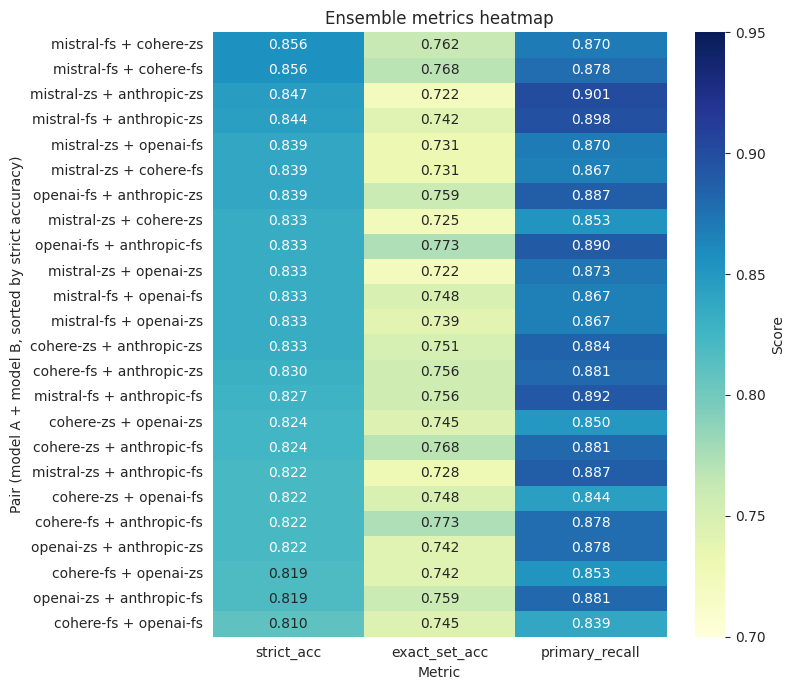

In [ ]:
metrics_for_heat = ensemble_df.set_index("pair")[["strict_acc", "exact_set_acc", "primary_recall"]]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    metrics_for_heat,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.7,
    vmax=0.95,
    cbar_kws={"label": "Score"},
    ax=ax
)
ax.set_title("Ensemble metrics heatmap")
ax.set_ylabel("Pair (model A + model B, sorted by strict accuracy)")
ax.set_xlabel("Metric")
plt.tight_layout()
plt.savefig("ensemble_heatmap.png", dpi=400, bbox_inches="tight")
plt.show()

In [ ]:
single_metrics = [
    {"name": "mistral-zs (single)", "strict_acc": 0.8017, "exact_set_acc": 0.6941, "primary_recall": 0.8215},
    {"name": "cohere-zs (single)", "strict_acc": 0.8130, "exact_set_acc": 0.6969, "primary_recall": 0.8159},
    {"name": "openai-zs (single)", "strict_acc": 0.8187, "exact_set_acc": 0.7394, "primary_recall": 0.8442},
    {"name": "anthropic-zs (single)", "strict_acc": 0.8470, "exact_set_acc": 0.7564, "primary_recall": 0.8980},
    {"name": "mistral-fs (single)", "strict_acc": 0.8272, "exact_set_acc": 0.7450, "primary_recall": 0.8414},
    {"name": "cohere-fs (single)", "strict_acc": 0.8385, "exact_set_acc": 0.7592, "primary_recall": 0.8555},
    {"name": "openai-fs (single)", "strict_acc": 0.8215, "exact_set_acc": 0.7450, "primary_recall": 0.8470},
    {"name": "anthropic-fs (single)", "strict_acc": 0.8244, "exact_set_acc": 0.7592, "primary_recall": 0.8810},
]

combined_rows = []
for s in single_metrics:
    combined_rows.append({"type": "single", "name": s["name"], **{k: v for k, v in s.items() if k != "name"}})
for _, row in ensemble_df.iterrows():
    combined_rows.append({
        "type": "ensemble",
        "name": f"{row['pair']} (via {row['third']})",
        "strict_acc": row["strict_acc"],
        "exact_set_acc": row["exact_set_acc"],
        "primary_recall": row["primary_recall"],
    })

combined_df = pd.DataFrame(combined_rows).sort_values("strict_acc", ascending=False).reset_index(drop=True)
print("=== All configurations sorted by strict accuracy ===")
print(combined_df.to_string(index=False))

=== All configurations sorted by strict accuracy ===
    type                                   name  strict_acc  exact_set_acc  primary_recall
ensemble mistral-fs + cohere-fs (via anthropic)    0.855524       0.767705        0.878187
ensemble mistral-fs + cohere-zs (via anthropic)    0.855524       0.762040        0.869688
ensemble mistral-zs + anthropic-zs (via cohere)    0.847025       0.722380        0.900850
  single                  anthropic-zs (single)    0.847000       0.756400        0.898000
ensemble mistral-fs + anthropic-zs (via cohere)    0.844193       0.742210        0.898017
ensemble openai-fs + anthropic-zs (via mistral)    0.838527       0.759207        0.886686
ensemble mistral-zs + cohere-fs (via anthropic)    0.838527       0.730878        0.866856
ensemble    mistral-zs + openai-fs (via cohere)    0.838527       0.730878        0.869688
  single                     cohere-fs (single)    0.838500       0.759200        0.855500
ensemble mistral-zs + cohere-zs (via 

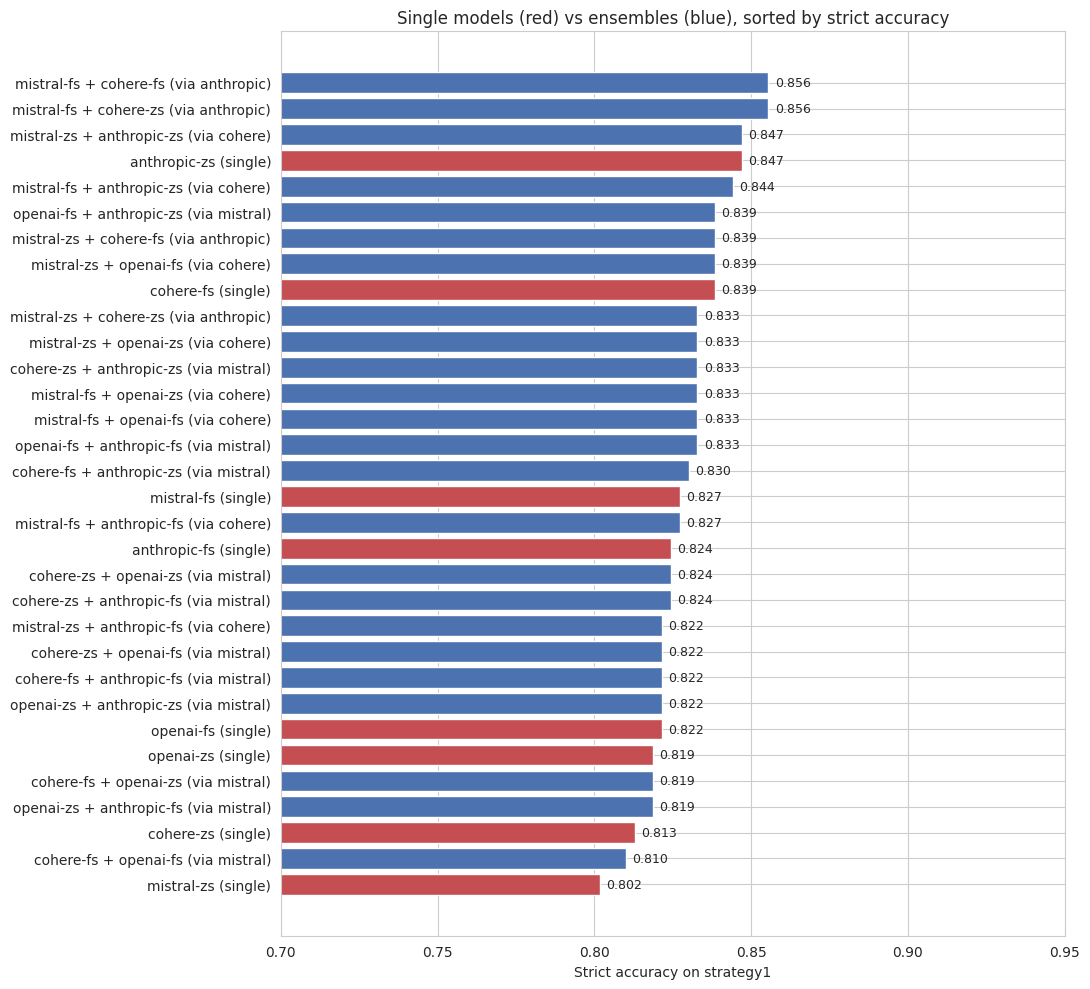

In [ ]:
fig, ax = plt.subplots(figsize=(11, 10))
colors = ["#C44E52" if t == "single" else "#4C72B0" for t in combined_df["type"]]
ax.barh(combined_df["name"], combined_df["strict_acc"], color=colors)
ax.set_xlabel("Strict accuracy on strategy1")
ax.set_title("Single models (red) vs ensembles (blue), sorted by strict accuracy")
ax.set_xlim(0.7, 0.95)
ax.invert_yaxis()

for i, v in enumerate(combined_df["strict_acc"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ensemble_vs_single.png", dpi=400, bbox_inches="tight")
plt.show()